В ходе тестирования одной гипотезы целевой группе была предложена **новая механика оплаты услуг на сайте**, у контрольной группы оставалась базовая механика. В качестве задания вам необходимо проанализировать итоги эксперимента и сделать вывод, **стоит ли запускать новую механику оплаты на всех пользователей**

#### Входные данные:
- groups.csv – файл с информацией о принадлежности пользователя к контрольной или экспериментальной группе (А – контроль, B – целевая группа) 

- group_add.csv – дополнительный файл с пользователями, который вам прислали спустя 2 дня после передачи данных

- active_studs.csv – файл с информацией о пользователях, которые зашли на платформу в дни проведения эксперимента
 
- checks.csv – файл с информацией об оплатах пользователей в дни проведения эксперимента

In [4]:
# импортируем необходимые библиотеки
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as st

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

from scipy.stats import levene

In [5]:
# читаем файлы и создаем датафреймы
active_studs = pd.read_csv('active_studs.csv')
checks = pd.read_csv('checks.csv', sep=';')
group_add = pd.read_csv('group_add.csv')
groups = pd.read_csv('groups.csv', sep=';')

# 1. Предварительный анализ данных

## 1.1. groups
принадлежность пользователя к контрольной или экспериментальной группе **(А - контрольная, В - экспериментальная)**

In [6]:
groups.head()

,id,grp
0,1489,B
1,1627,A
2,1768,B
3,1783,B
4,1794,A


In [7]:
groups.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74484 entries, 0 to 74483
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      74484 non-null  int64 
 1   grp     74484 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


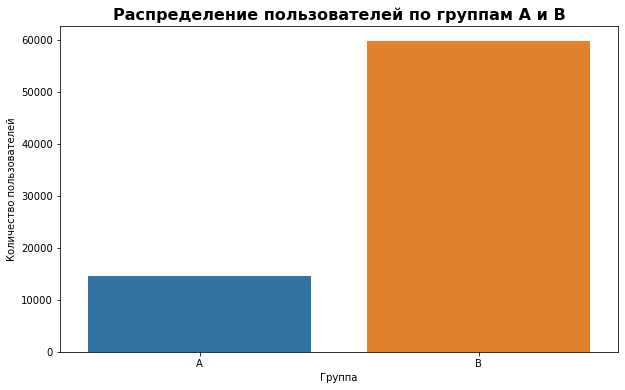

In [31]:
# размеры контрольной и тестовой группы

plt.figure(figsize=(10, 6))
sns.countplot(x='grp', data=groups, order=['A', 'B'])
plt.title('Распределение пользователей по группам A и B', fontsize=16, fontweight='bold')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.show()

In [9]:
groups['grp'].value_counts() # размеры контрольной и тестовой группы

B    59813
A    14671
Name: grp, dtype: int64

In [10]:
groups['id'].nunique() # проверка на дубли

74484

В датафрейме данные о 74484 пользователях. Дублей, пропусков, аномалий нет. Но размер контрольной группы в 4 раза больше размера тестовой группы. В таком случае могут быть сложности с получением статзначимых различий.

## 1.2. group_add
доп. файл с пользователями, который прислали через 2 дня

In [11]:
group_add.head()

,id,grp
0,5694584,B
1,5694830,B
2,5695057,B
3,5698872,B
4,5699067,B


In [12]:
group_add.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      92 non-null     int64 
 1   grp     92 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.6+ KB


In [13]:
group_add['grp'].value_counts() # кол-во пользователей в каждой группе

B    70
A    22
Name: grp, dtype: int64

In [14]:
group_add['id'].nunique() # проверка на дубли

92

В датасете дополнительные данные о 92 пользователях, которые распределены в группы А и В. При этом в группе В в 3 раза больше пользователей. Пропусков, аномалий и дублей нет.

Объединим датасеты groups и group_add для полноты данных.

In [15]:
all_groups = pd.concat([groups, group_add], ignore_index=True)

all_groups.head()

,id,grp
0,1489,B
1,1627,A
2,1768,B
3,1783,B
4,1794,A


In [16]:
all_groups.info() #все корректно объединилось

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74576 entries, 0 to 74575
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      74576 non-null  int64 
 1   grp     74576 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


In [17]:
all_groups['grp'].value_counts() # размеры групп

B    59883
A    14693
Name: grp, dtype: int64

In [18]:
all_groups['id'].nunique() # дублей, пропусков нет

74576

## 1.3. active_studs
информация о пользователях, которые зашли на платформу в дни эксперимента

In [19]:
active_studs.head()

,student_id
0,581585
1,5723133
2,3276743
3,4238589
4,4475369


In [20]:
active_studs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8341 entries, 0 to 8340
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   student_id  8341 non-null   int64
dtypes: int64(1)
memory usage: 65.3 KB


In [21]:
active_studs.nunique() # провекрка на дубли

student_id    8341
dtype: int64

В датасете всего содержится 8341 значения. Все уникальные. Пропусков, дублей, аномалий нет.

Из полученных значений мы видим, что не все пользователи, распределенные по группам, были активны (в active_studs 8341 значение, в all_groups 74576 значения). Нам нужно отобрать только активных пользователей.

In [22]:
# добавляем столбец с информацией об активности пользователя
all_groups['active'] = all_groups['id'].isin(active_studs['student_id']) 
all_groups

,id,grp,active
0,1489,B,False
1,1627,A,True
2,1768,B,False
3,1783,B,False
4,1794,A,False
...,...,...,...
74571,200247820,B,False
74572,201032527,B,False
74573,201067612,B,False
74574,201067653,B,False


In [23]:
# отбираем активных пользователей
active_group = all_groups.query('active == True')
active_group.head()

,id,grp,active
1,1627,A,True
10,2085,B,True
12,2215,B,True
43,3391,A,True
45,3401,B,True


## 1.4. checks
информация об оплатах пользователей в дни проведения эксперимента

In [24]:
checks.head()

,student_id,rev
0,1627,990.0
1,3185,690.0
2,25973,690.0
3,26280,690.0
4,100300,990.0


In [25]:
checks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   student_id  541 non-null    int64  
 1   rev         541 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 8.6 KB


In [26]:
checks = checks.rename(columns={'student_id' : 'id'})

In [27]:
checks['id'].nunique() # количество уникальных пользователей, совершивших оплату

541

In [28]:
# объединим датафреймы, добавив информацию об оплатах в дни проведения эксперимента
df = active_group.merge(checks, on='id', how='left').fillna(0)

df # датафрейм со всеми активными пользователями и их данных об оплате

,id,grp,active,rev
0,1627,A,True,990.0
1,2085,B,True,0.0
2,2215,B,True,0.0
3,3391,A,True,0.0
4,3401,B,True,0.0
...,...,...,...,...
8336,5760471,B,True,0.0
8337,5777081,B,True,0.0
8338,5870856,A,True,0.0
8339,5945085,B,True,0.0


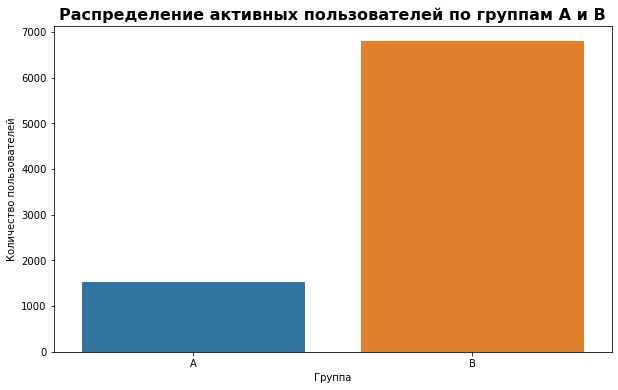

In [32]:
# распределение активных пользователей по группам

plt.figure(figsize=(10, 6))
sns.countplot(x='grp', data=df, order=['A', 'B'])
plt.title('Распределение активных пользователей по группам A и B', fontsize=16, fontweight='bold')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.show()

In [37]:
# проверим, все ли платящие пользователи были активными
active_paying = df.query('rev > 0')
active_paying

,id,grp,active,rev
0,1627,A,True,990.0000
10,100300,B,True,990.0000
12,108270,B,True,290.0000
246,264473,B,True,1900.0001
279,274352,B,True,690.0000
...,...,...,...,...
8312,5645737,B,True,1900.0000
8314,5651566,B,True,1900.0000
8316,5662322,B,True,1900.0000
8323,5681918,B,True,1900.0000


Количество активных и платящих пользователей (392) не сходится с общим количеством платящих пользователей (541). Получается, что 149 пользователей совершили оплату, но НЕ были активными. Следовательно, в датафрейме checks есть аномальные значения, для дальнейшего анализа они не будут рассматриваться.

Такое могло произойти, например, если у пользователя подключено автоматическое списание денежных средств, либо если пользователь совершил покупку через приложение (в нашем исследовании во внимание берется оплата на сайте), либо если произошел баг системы.

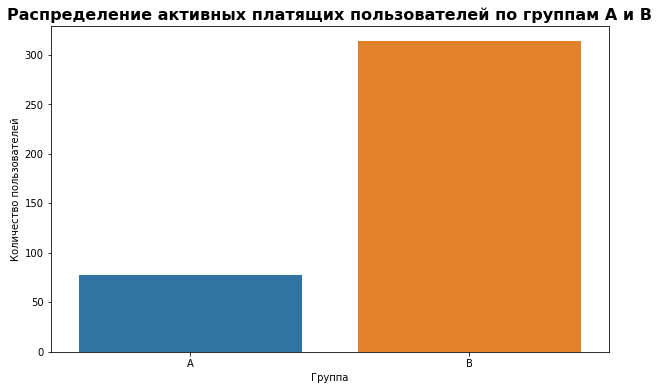

In [38]:
# распределение активных платящих пользователей по группам

plt.figure(figsize=(10, 6))
sns.countplot(x='grp', data=active_paying, order=['A', 'B'])
plt.title('Распределение активных платящих пользователей по группам A и B', fontsize=16, fontweight='bold')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.show()

## Выводы по предварительному анализу данных

Анализ показал, что в таблицах groups, group_add, active_studs отсутствуют аномалии, пропуски, дубли, однако наблюдается аномалия в checks, которая заключается в том, что есть неактивные пользователи, совершившие оплату. 

Для более корректного проведения A/B-теста необходимо, чтобы контрольная и тестовая группы были примерно одинакового размера, однако в наших данных наблюдается дисбаланс между группами (размер тестовой группы превышает размер контрольной группы), что может повлиять на риск возникновения ошибки 2 рода (риск НЕ отклонить нулевую гипотезу, даже если есть статзначимые различия).

# 2. Анализ данных
**Стоит ли запускать новую механику оплаты на всех пользователей?**

Важная метрика, которая будет проанализирована - CR (конверсия в оплату) в каждой группе, она покажет, насколько новый способ оплаты удобнее. Помимо этого, важно рассмотреть ARPPU (средний доход с платящего пользователя) и ARPU (средний доход с пользователя).

In [39]:
# создадим сводную таблицу по группам для последующего анализа
df_pivot = df.groupby('grp', as_index=False).agg(active_users = ('id', 'nunique'), 
                                                 paying_users = ('rev', lambda x: (x > 0).sum()),
                                                 total_revenue = ('rev', 'sum')
                                                )
df_pivot

,grp,active_users,paying_users,total_revenue
0,A,1538,78,72820.0000
1,B,6803,314,394974.0035


In [40]:
# считаем метрики

df_pivot['CR'] = round(
    (df_pivot['paying_users'] 
     / df_pivot['active_users']
    ) 
    * 100, 
    2
) # конверсия в оплату

df_pivot['ARPU'] = round(
    (df_pivot['total_revenue'] 
     / df_pivot['active_users']
    ), 
    2
) # средний доход с пользователя

df_pivot['ARPPU'] = round(
    (df_pivot['total_revenue'] 
     / df_pivot['paying_users']
    ), 
    2
) # средний доход с платящего пользователя

df_pivot

,grp,active_users,paying_users,total_revenue,CR,ARPU,ARPPU
0,A,1538,78,72820.0000,5.07,47.35,933.59
1,B,6803,314,394974.0035,4.62,58.06,1257.88


В группе А (контрольная группа) всего 1538 активных пользователей, из них 78 платящих, конверсия в оплату составляет 5,1%. В группе В (тестовая группа) всего 6803 активных пользователя, из них платящих 314, конверсия в оплату составляет 4,6%. **Конверсия в оплату в тестовой группе снизилась**, при этом ARPU и ARPPU увеличились на 23% и 35% соответственно.

Перед тем, как делать вывод об эффективности новой механики оплаты, необходимо проверить, **насколько различия статистически значимы**.

# 3. Проверка гипотез

## 1. CR

H0: конверсии в покупку в контрольной и тестовой группе не отличаются

H1: конверсии в покупку в контрольной и тестовой группе отличаются

Для проверки равенства двух конверсий используем z-тест.

In [41]:
# количество покупок в каждой группе
successes = df_pivot.set_index('grp').loc[['A', 'B'], 'paying_users'].values

# размер групп
nobs = df_pivot.set_index('grp').loc[['A', 'B'], 'active_users'].values

z_stat, p_value = proportions_ztest(successes, nobs)

print(z_stat, p_value)

0.7629884495263746 0.445470284371589


p_value > 0.05, следовательно, мы не можем отвергнуть H0, значит, **конверсии в оплату в группах статзначимо не отличаются.**

## 2. ARPPU и ARPU

Перед тем, как выбрать тест для проверки равенства средних, нужно проверить дисперсии, нормальность распределения, наличие выбросов.

### 2.1. ARPPU

Text(0, 0.5, 'Плотность распределения')

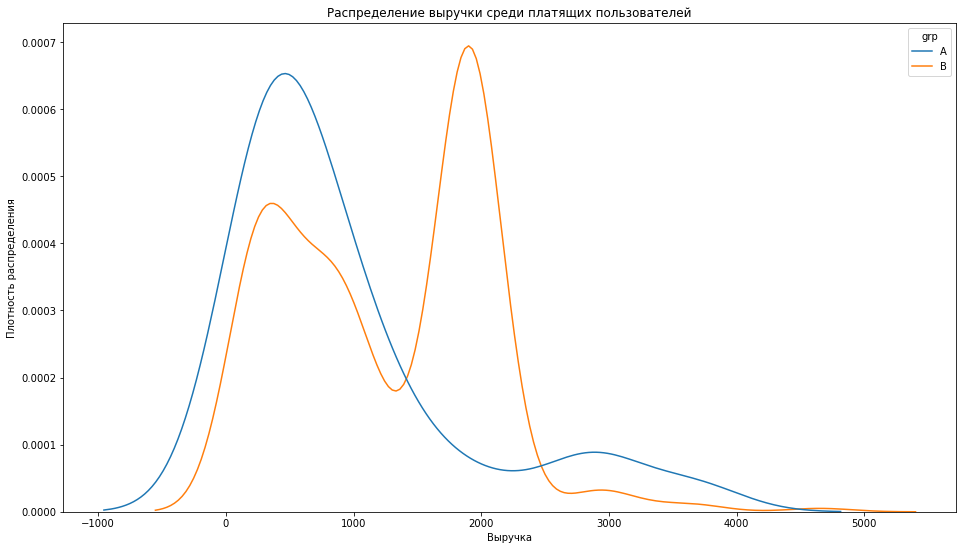

In [42]:
# проверим нормальность распределения выручки среди активных платящих пользователей

paying_users = df.loc[df['rev'] > 0] # отбираем платящих пользователей из общего датафрейма df

plt.figure(figsize=(16, 9))
sns.kdeplot(data=paying_users, x='rev', hue='grp', common_norm=False)
plt.title('Распределение выручки среди платящих пользователей')
plt.xlabel('Выручка')
plt.ylabel('Плотность распределения')

По графику группы А видно ассиметричное распределение, скошенное влево. Справа есть выбросы с более крупными платежами.

У графика группы В наблюдается бимодальность (два пика), распределение смещено правее по сравнению с группой А. Можно предположить, что пользователи тестовой группы стали платить больше.


**Проверим равенство дисперсий для двух групп с помощью теста Левена.**

H0: дисперсии в группах равны

H1: дисперсии в группах не равны

*(если p < 0.05, отвергаем H0)*

In [43]:
# проверим равенство дисперсий для двух групп с помощью теста Левена

group_A_pay = df[(df.grp == 'A') & (df.rev > 0)]['rev']
group_B_pay = df[(df.grp == 'B') & (df.rev > 0)]['rev']

stat, p = levene(group_A_pay, group_B_pay)

print(stat, p)

3.075681699981606 0.08025675761347022


p > 0.05, следовательно, мы не можем отвергнуть нулевую гипотезу и считаем, что **дисперсии групп равны.**

Так как в данных имеются выбросы и распределение ненормальное, для проверки равенства средних будет использован **бутстрап.**

In [44]:
def boot_ab(paying_users, reps=5000, seed=2112):
    np.random.seed(seed)
    boot_data = []
    
    grp_a = paying_users[paying_users['grp'] == 'A']['rev']
    grp_b = paying_users[paying_users['grp'] == 'B']['rev']
    
    for i in range(reps):
    
        sample_a = grp_a.sample(frac=1, replace=True)
        sample_b = grp_b.sample(frac=1, replace=True)

        sample_stat = sample_b.mean() - sample_a.mean()
        boot_data.append(sample_stat)
    
    return np.array(boot_data)

In [45]:
boot_result = boot_ab(paying_users)

mean_boot_result = boot_result.mean()

conv_int = np.percentile(boot_result, [2.5, 97.5])

print(f"""Разница средних ARPPU: {round(mean_boot_result, 2)} у.е.
95% доверительный интервал: {conv_int}""")

Разница средних ARPPU: 323.93 у.е.
95% доверительный интервал: [100.78775467 533.90530522]


В среднем ARPPU в группе В на 323.93 у.е. больше, чем в группе А.
В доверительный интервал не входит 0, следовательно, **разница между ARPPU двух групп статзначимо отличается.**

### 2.1. ARPU

Text(0, 0.5, 'Плотность распределения')

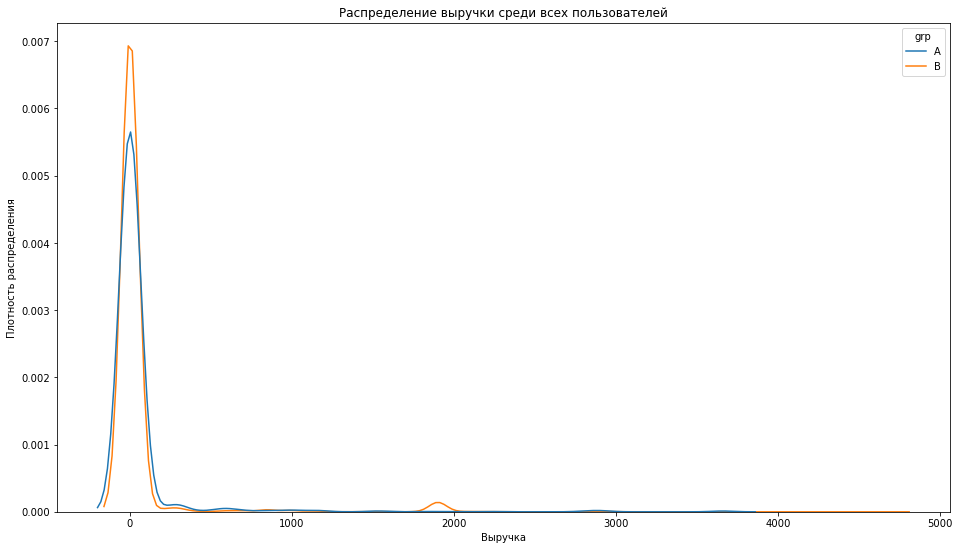

In [46]:
# проверим нормальность распределения выручки среди активных платящих пользователей

plt.figure(figsize=(16, 9))
sns.kdeplot(data=df, x='rev', hue='grp', common_norm=False)
plt.title('Распределение выручки среди всех пользователей')
plt.xlabel('Выручка')
plt.ylabel('Плотность распределения')

Оба графика ассиметричны со сдвигом влево. У группы В наблюдается выброс около 2000 у.е.

Видно, что ARPU группы В больше, чем в группе А. Проверим, насколько разница статзначима. Перед выбором способа проверки равенства средних проверим дисперсию с помощью теста Левена.

H0: дисперсии в группах равны

H1: дисперсии в группах не равны

*(если p < 0.05, отвергаем H0)*

In [47]:
# проверим равенство дисперсий для двух групп с помощью теста Левена

group_A = df[(df.grp == 'A') & (df.rev > 0)]['rev']
group_B = df[(df.grp == 'B') & (df.rev > 0)]['rev']

stat, p = levene(group_A, group_B)

print(stat, p)

3.075681699981606 0.08025675761347022


p > 0.05, следовательно, мы не можем отвергнуть нулевую гипотезу и предполагаем, что дисперсии равны.

Так как дисперсии равны, наблюдения независимы, сильных выбросов (за исключением небольшого выброса у группы В около 2000 у.е.) нет, для проверки равенства средних будет использован t-тест (t-тест работает с ненормальным распределением, если размер выборки > 30, как в данном случае).

H0: APRU двух групп не отличаются 

H1: ARPU двух групп отличаются

In [48]:
control = df.query('grp == "A"')['rev']
test = df.query('grp == "B"')['rev']

st.ttest_ind(control, test)

TtestResult(statistic=-1.2253411073793445, pvalue=0.22048133326988378, df=8339.0)

p > 0.05, следовательно, **ARPU двух групп статзначимо не отличается.**

# Выводы

- конверсия в оплату статистически значимо не изменилась 
- ARPU (средняя выручка с пользователя) статистически значимо не изменилось
- ARPPU (средняя выручка с платящего пользователя) стастистически значимо увеличилось в тестовой группе на 323.93 у.е., то есть пользователи стали платить больше. Вопрос в том, насколько это связано именно с новой механикой оплаты, но изменение есть.


# Резюме

В ходе работы над заданием был проведен предварительный анализ данных, в ходе которого были выявлены аномалии в таблицы checks (часть пользователей совершили оплату, но не были активными), это могло случиться, например, если у пользователей была подключена автоматическая оплата или если пользователь совершал оплату через приложение, в остальных таблицах аномальных значений, дублей и пропусков нет. В ходе анализа было выявлено, что размеры тестовой и контрольной группы неравны, что повышает риск возникновения ошибки 2 рода при проведении A/B-теста.

Затем были определены ключевые метрики **(CR, ARPU, ARPPU)** для анализа и составлена сводная таблица по группам:

- группа А (контрольная): 1538 активных пользователей, из них 78 платящих. Конверсия в оплату - 5.1%.
- группа В (тестовая): 6803 активных пользователя, из них 314 платящих. Конверсия в оплату - 4,6%.

**Конверсия в оплату** в тестовой группе **снизилась**, при этом **ARPU и ARPPU увеличились** на 23% и 35% соответственно. Далее были проведены статистические тесты, чтобы посмотреть, являются ли изменения статистически значимыми.

Для проверки равенства двух конверсий был использован z-тест, который показал p > 0.05, что не позволило нам отвергнуть H0, значит, **конверсии в оплаты статистически значимы не различаются**.

Равенство двух средних ARPPU было проверено с помощью бутстрапа. Анализ показал p < 0.05, следовательно, **изменение ARPPU является статистически значимым, в среднем ARPPU в тестовой группе увеличилось на 323.93 у.е.**

Равенство двух средних ARPU было проверено с помощью t-теста, который показал p > 0.05, следовательно, изменение **ARPU не статзначимо.**

Исходя из проведенного анализа, можно сделать вывод, что введение новой механики не испортит конверсию в оплату и увеличит выручку с тех пользователей, кто уже платил ранее, но не повлияет на тех, кто ранее не платил. Стоит помнить, что анализ был проведен на разных по размеру выборках, что повышает вероятность получения ошибки 2 рода. Целесообразно уровнять группы и провести исследование повторно. В данном случае наиболее важная метрика, на мой взгляд, CR (конверсия в оплату) не показала статзначимого изменения, поэтому по получившимсся результатам, думаю, что **вводить новую механику на всех пользователей не стоит.**

# SQL

### Сегментация клиентов для персонализированного маркетинга

CRM-отдел строит систему сегментации клиентов для триггерных рассылок на основе истории покупок. Сегмент клиента определяет тип маркетинговой коммуникации.

In [ ]:
WITH orders_data AS (
  SELECT
    customer_id,
    COUNT(order_id) AS orders_count,
    AVG(
      EXTRACT(
        EPOCH
        FROM
          (
            order_delivered_customer_time - order_created_time
          )
      ) / 86400.0
    ) AS avg_delivery_days
FROM
  orders
WHERE
  order_status = 'Delivered'
GROUP BY
  customer_id
),

actions_data AS (
  SELECT
    customer_id,
    COUNT(*) FILTER (
      WHERE
        event_type = 'Purchase'
    ) AS purchase_events_count
  FROM
    customer_actions
  GROUP BY
    customer_id
),

customers_data AS (
  SELECT
    c.customer_id,
    c.customer_city,
    DATE(c.created_at) AS registration_date,
    ('2024-03-31' :: DATE - DATE(c.created_at)) AS days_since_registration,
    COALESCE(o.orders_count, 0) AS orders_count,
    COALESCE(a.purchase_events_count, 0) AS purchase_events_count,
    o.avg_delivery_days
  FROM
    customers c
    LEFT JOIN orders_data o ON c.customer_id = o.customer_id
    LEFT JOIN actions_data a ON c.customer_id = a.customer_id
)

SELECT
  customer_id,
  customer_city,
  registration_date,
  days_since_registration,
  orders_count,
  purchase_events_count,
  avg_delivery_days,
  CASE
    WHEN orders_count >= 3 THEN 'Постоянный'
    WHEN orders_count IN (1, 2) THEN 'Разовый'
    WHEN orders_count = 0
    AND days_since_registration > 30 THEN 'Неактивный'
    WHEN orders_count = 0
    AND days_since_registration <= 30 THEN 'Новый'
  END AS segment 
FROM
  customers_data

## 3.1. Функция для автоматической подгрузки информации из файла и пересчета метрик

In [11]:
# пишем функцию
def add_new_file_and_update_metrics(groups_file, new_file, active_file, checks_file):
    
    # читаем файлы
    groups = pd.read_csv(groups_file, sep=None, engine='python')
    active = pd.read_csv(active_file, sep=None, engine='python')
    checks = pd.read_csv(checks_file, sep=None, engine='python')
    groups_add = pd.read_csv(new_file, sep=None, engine='python') # новый файл

    # приводим названия колонок в новом датафрейме к нужному виду
    groups_add.columns = [col.lower() for col in groups_add.columns]
    
    id_cols = [col for col in groups_add.columns if 'id' in col] # среди всех колонок ищем ту, где есть id  
    id_grp = [col for col in groups_add.columns if 'grp' in col or 'group' in col] # среди всех колонок ищем ту, где есть grp или group 
    
    if not id_cols or not id_grp:
        print('Не найдены нужные колонки') # если колонок с таким названием нет, выводим предупреждение
    
    # переименовываем колонки в соответствии с названиями в исходной таблице
    groups_add = groups_add.rename(columns = {
        id_cols[0] : 'id',
        id_grp[0] : 'grp'
    }) 
    
    # объединяем новый файл с исходным по группам
    all_groups = pd.concat([groups, groups_add], ignore_index=True)
    
    # отбираем только активных пользователей
    all_groups['active'] = all_groups['id'].isin(active['student_id'])
    active_group = all_groups.query('active == True')
    
    # переименовываем столбец в checks для удобства при дальнейшем объединении
    checks = checks.rename(columns={'student_id' : 'id'})
    
    # добавляем к активным пользователям информацию по оплатам
    df = active_group.merge(checks, on='id', how='left').fillna(0)
    
    # считаем метрики
    metrics = (df.groupby('grp', as_index=False)
               .agg(
                   active_users = ('id', 'nunique'), 
                   paying_users = ('rev', lambda x:(x > 0).sum()), 
                   total_revenue = ('rev', 'sum'))
              )
    
    metrics['CR'] = round((metrics['paying_users'] / metrics['active_users']) * 100, 2)
    metrics['ARPU'] = round(metrics['total_revenue'] / metrics['active_users'], 2)
    metrics['ARPPU'] = round(metrics['total_revenue'] / metrics['paying_users'], 2)
    
    return(metrics)

In [12]:
# проверка работоспособности функции
update_metrics = add_new_file_and_update_metrics('groups.csv', 'group_add.csv', 'active_studs.csv', 'checks.csv')

print(update_metrics)

  grp  active_users  paying_users  total_revenue    CR   ARPU    ARPPU
0   A          1538            78     72820.0000  5.07  47.35   933.59
1   B          6803           314    394974.0035  4.62  58.06  1257.88


## 3.2. Функция, которая строит графики по получаемым метрикам

In [87]:
def metrics_plots(metrics):
    
    metric_names = ['CR', 'ARPU', 'ARPPU']
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 9))
    fig.suptitle('Метрики по группам', fontsize=22, fontweight='bold')
    
    for i, metric in enumerate(metric_names):
        
        sns.barplot(data=metrics, x='grp', y=metric, ax=axes[i])
        
        axes[i].set_title(metric, fontsize=14)
        axes[i].set_ylabel(' ')
        
        if i == 1:
            axes[i].set_xlabel('Группа', fontsize=18)
        else:
            axes[i].set_xlabel(' ')

        
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

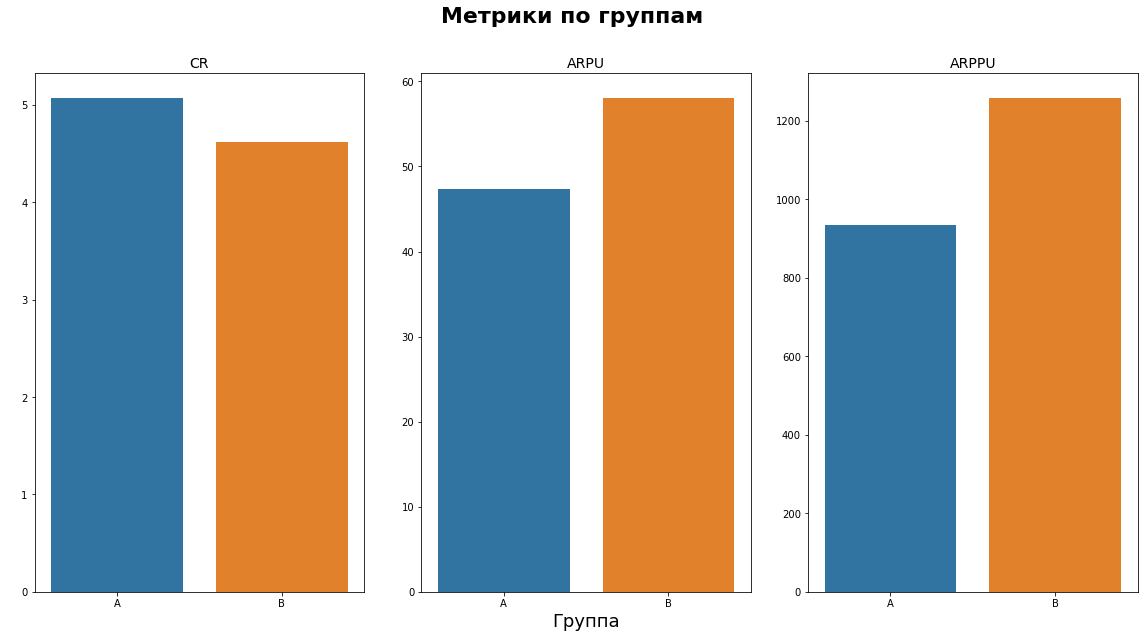

In [89]:
# проверка работоспособности функций

update_metrics = add_new_file_and_update_metrics('groups.csv', 'group_add.csv', 'active_studs.csv', 'checks.csv')

metrics_plots(update_metrics)